# An Introduction to Word Embeddings

# Download Libraries to perform NLP Related task

In [1]:
! pip install spacy csv

ERROR: Could not find a version that satisfies the requirement csv (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for csv


## Training Word Embeddings 

In [2]:
import os
import csv
import spacy
import gensim


In [3]:


class Corpus(object):
    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")

    def __iter__(self):
        with open(self.filename, "r", encoding="utf-8") as f:
            reader = csv.reader(f, delimiter=",")
            for row in reader:
                if not row:
                    continue
                # assume abstract is in second column if present, otherwise use first
                abstract = row[1] if len(row) > 1 else row[0]
                tokens = [t.text.lower() for t in self.nlp(abstract)]
                yield tokens

# Notebook is in Day-2/, arxiv.csv is in the repository root — use relative path
documents = Corpus("../arxiv.csv")

In [4]:
documents = list(documents)
documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [5]:
model = gensim.models.Word2Vec(documents, vector_size=100, window=5, min_count=100)

In [6]:
model.wv["nlp"]

array([ 1.0478088 , -1.4828181 ,  1.5822881 , -1.6550027 ,  0.13105358,
       -1.0030336 ,  1.8837844 , -0.18760143, -1.0628654 ,  0.9130649 ,
       -0.40097144, -1.2751029 ,  1.4956813 ,  0.6445497 ,  0.4306641 ,
       -0.0881334 , -0.9038962 ,  1.8066063 , -0.12330461,  1.3430542 ,
        0.702061  ,  0.3179483 ,  1.0734588 , -1.2076311 , -1.8641115 ,
       -1.4269131 ,  2.273899  ,  0.3694882 ,  2.7036877 ,  0.74489486,
        0.5153335 ,  0.7171552 ,  1.2543098 ,  0.77580696, -1.3751206 ,
       -0.54842854,  0.23162834, -3.8915482 , -0.24574898,  1.8758578 ,
       -1.4728957 , -2.2082121 ,  2.346359  ,  2.2381167 , -2.310238  ,
        0.13233058,  1.2277844 ,  1.2898709 ,  0.63068616, -1.7804173 ,
        2.0179007 , -0.9440291 ,  0.40886128, -0.21458511,  2.0946844 ,
        0.05352143,  0.04030177,  0.2968512 ,  2.2854905 , -0.41062403,
        1.0759447 ,  3.0924194 , -1.3728741 , -0.03525805,  0.22742459,
       -0.11845381, -1.4274107 , -3.0297034 ,  1.7861465 , -0.92

In [7]:
print(model.wv.similarity("nmt", "smt"))
print(model.wv.similarity("nmt", "ner"))

0.67722535
0.38531643


In [8]:
model.wv.most_similar(positive=["tree"], topn = 10)

[('trees', 0.7962108850479126),
 ('constituency', 0.7095067501068115),
 ('parse', 0.6928614974021912),
 ('constituent', 0.6611606478691101),
 ('recursive', 0.642932116985321),
 ('dependency', 0.6240477561950684),
 ('formalism', 0.6114964485168457),
 ('syntax', 0.6105856895446777),
 ('parser', 0.6082050204277039),
 ('transition', 0.5832951068878174)]

In [9]:
print(model.wv.doesnt_match("lstm cnn gru svm transformer".split()))
print(model.wv.doesnt_match("bert word2vec gpt-2 roberta xlnet".split()))
print(model.wv.doesnt_match("word2vec bert glove fasttext elmo".split()))

svm
word2vec
bert


# Plotting Embedding

In [10]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

target_word = "bert"
selected_word = [w[0] for w in model.wv.most_similar(target_word, topn=200)] + [target_word]
embeddings = [model.wv[w] for w in selected_word] +  model.wv["bert"]

mapped_embeddings = TSNE(n_components=2, metric = 'cosine',  init = 'pca') . fit_transform(embeddings)

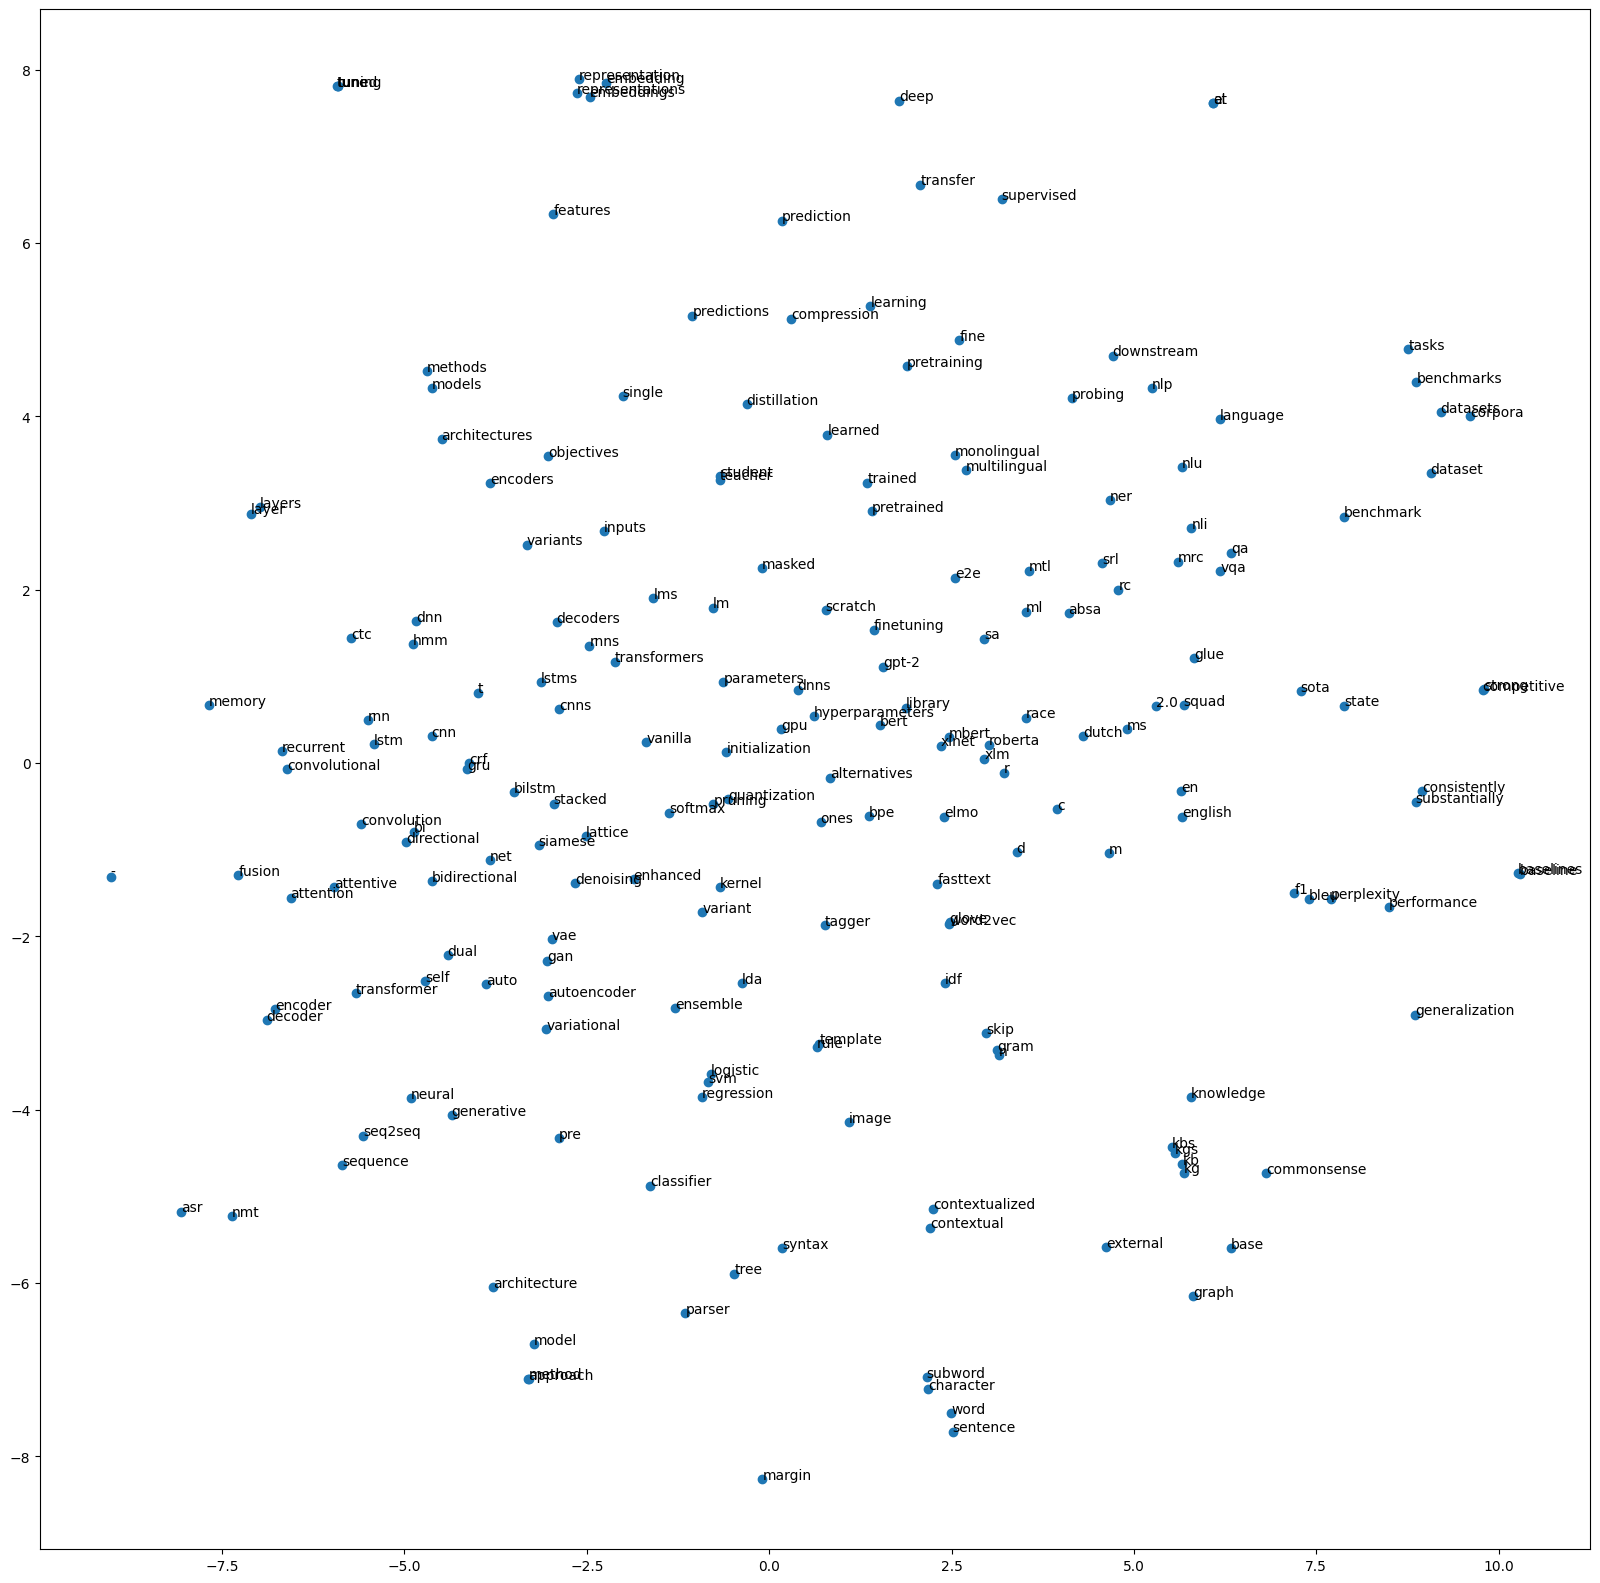

In [11]:
plt.figure(figsize=(20,20))
x = mapped_embeddings[:,0]
y = mapped_embeddings[:,1]
plt.scatter(x, y)

for i, txt in enumerate(selected_word):
    plt.annotate(txt, (x[i], y[i]))